In [8]:
from rdkit import Chem
from rdkit.Chem import rdqueries

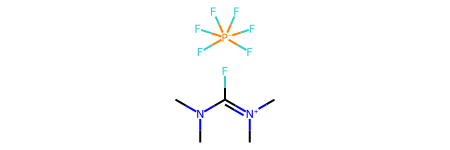

In [9]:
# 高价原子绕过价态检查
m = Chem.MolFromSmiles('F[P-](F)(F)(F)(F)F.CN(C)C(F)=[N+](C)C',sanitize=False)
m

In [10]:
# 绕过之后杂化状态不确定
q = rdqueries.AtomNumEqualsQueryAtom(15)
phosphorus = m.GetAtomsMatchingQuery(q)[0]
print(phosphorus.GetHybridization())

UNSPECIFIED


In [11]:
# 做局部的非严格检查
m.UpdatePropertyCache(strict=False)
Chem.SanitizeMol(
    m,
    Chem.SanitizeFlags.SANITIZE_FINDRADICALS |
    Chem.SanitizeFlags.SANITIZE_KEKULIZE |
    Chem.SanitizeFlags.SANITIZE_SETAROMATICITY |
    Chem.SanitizeFlags.SANITIZE_SETCONJUGATION |
    Chem.SanitizeFlags.SANITIZE_SETHYBRIDIZATION |
    Chem.SanitizeFlags.SANITIZE_SYMMRINGS,
    catchErrors=True
)
print(phosphorus.GetHybridization())

SP3D2


In [20]:
# 安全构建分子，先绕过检查再发现问题
# N原子成键数不满足要求
m = Chem.MolFromSmiles('CN(C)(C)C', sanitize=False)
problems = Chem.DetectChemistryProblems(m)
print(problems)
# 环无法写出凯库勒式（单双键交替）
m2 = Chem.MolFromSmiles('c1cncc1',sanitize=False)
problems = Chem.DetectChemistryProblems(m2)
print(problems)

(<rdkit.Chem.rdchem._cppAtomValenceException object at 0x10fd63a00>,)
(<rdkit.Chem.rdchem._cppAtomKekulizeException object at 0x10fd63bc0>,)


[14:05:14] Explicit valence for atom # 1 N, 4, is greater than permitted
[14:05:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4


In [ ]:
# 过渡金属配位键改为箭头
from rdkit.Chem.Draw import IPythonConsole

def is_transition_metal(at):
    n = at.GetAtomicNum()
    return (n>=22 and n<=29) or (n>=40 and n<=47) or (n>=72 and n<=79) 

def set_dative_bonds(mol, fromAtoms=(7,8)): # 只处理N/O两个原子的配位
    pt = Chem.GetPeriodicTable() # 周期表
    rwmol = Chem.RWMol(mol) # 可编辑对象RWMol
    rwmol.UpdatePropertyCache(strict=False) # 更新原子的性质缓存，不报价态错
    metals = [at for at in rwmol.GetAtoms() if is_transition_metal(at)] # 所有的常见d区过渡金属原子
    for metal in metals:
        for nbr in metal.GetNeighbors(): # 遍历金属原子的邻居原子
            if nbr.GetAtomicNum() in fromAtoms and \
               nbr.GetExplicitValence()>pt.GetDefaultValence(nbr.GetAtomicNum()) and \
               rwmol.GetBondBetweenAtoms(nbr.GetIdx(),metal.GetIdx()).GetBondType() == Chem.BondType.SINGLE: # 是N/O、超价态、单键连接
                rwmol.RemoveBond(nbr.GetIdx(),metal.GetIdx())
                rwmol.AddBond(nbr.GetIdx(),metal.GetIdx(),Chem.BondType.DATIVE)
    return rwmol

m = Chem.MolFromSmiles('CN(C)(C)[Pt]', sanitize=False)
m2 = set_dative_bonds(m)
m2

C[N](C)(C)->[Pt]


[14:31:05] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
